# Conformal Verification

## 0. Prepare workspace

### Imports

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from batch_generation import generate_random_batch
from plot_functions import plot_pb_trajectories, plot_nonconformity_scores
from evaluation_setup import EvaluationConfig, prepare_evaluation_context

import nonconformity
import plot_functions

### Prepare evaluation context

In [2]:
checkpoint_path = 'ren_standard_checkpoint.pt'
device = 'cpu'

horizon = 300
num_test_samples = 500
x0_std = 0.2
noise_std = 0.0
n_agents = 1

config = EvaluationConfig()

ctx = prepare_evaluation_context(
    checkpoint_path=checkpoint_path,
    device=device,
    config=config
)

eval_system = ctx['eval_system']
metric = ctx['metric']
x_target = ctx['x_target']
obs_centers = ctx['obs_centers']
obs_sigmas = ctx['obs_sigmas']
pb_loop = eval_system['pb_loop']

print('Evaluation context is ready.')
print(f"REN dims: {ctx['dims']}")
print(f"Missing keys: {list(ctx['load_result'].missing_keys)}")
print(f"Unexpected keys: {list(ctx['load_result'].unexpected_keys)}")

Evaluation context is ready.
REN dims: {'dim_in': 4, 'dim_out': 2, 'dim_internal': 4, 'dim_nl': 4}
Missing keys: ['x', 'init_x']
Unexpected keys: []


## 1. Conditional conformal verification pipeline

### Set up conformal parameters

In [3]:
# Non-conformity score
non_conformity_score = "pb_loss"

# Conditional vs marginal
conditional_verification = True

# Probability thresholds and certification dataset size
alpha = 0.05       # w/r draw of calibration data
delta = 0.05            # P w/r nonconformity score violation
m_cert = 1000           # Size of certification dataset
test_dataset_size = 1000
nb_experiments = 1000

#Calculate the shift in alpha for conditional certificates
if conditional_verification:
    epsilon_cert = np.sqrt(np.log(2 / delta) / (2 * m_cert))
else:
    epsilon_cert = 0

# Shift alpha
alpha_conditional = alpha - epsilon_cert

# Set seed for reproducibility
seed = 2
torch.manual_seed(seed)
np.random.seed(seed)

### Sample calibration dataset

In [4]:
# Sample noise realizations
calibration_w = generate_random_batch(batch_size=m_cert, horizon=horizon, n_agents=n_agents,
                                    x0_std=x0_std, noise_std=noise_std, device=device)

# Unroll trajectories with trained closed-loop model
traj = {}
pb_loop.eval()
with torch.no_grad():
    traj["x"], traj["u"], traj["w_hat"] = pb_loop.run(calibration_w)

### Find the conditional threshold of the non-conformity score on the calibration set

In [5]:
# Build non-conformity scorer from selector
scorer = nonconformity.build_scorer(
    non_conformity_score,
    pb_loss_config=nonconformity.PBLossConfig(
        x_target=x_target,
        q=ctx["Q"],
        r=ctx["R"],
        alpha_obs=config.alpha_obs,
        obs_centers=obs_centers,
        obs_sigmas=obs_sigmas,
        n_agents=n_agents,
    ),
)

# Compute all per-trajectory scores + conformal threshold
calibration_result = nonconformity.calibrate_nonconformity(
    trajectories=traj,
    scorer=scorer,
    alpha=alpha_conditional,
    finite_sample=True,
)

print(f"Conditional conformal threshold: {calibration_result.threshold.item():.6f}")

Conditional conformal threshold: 2.115349


### Empirically verify the calibration threshold on a test set

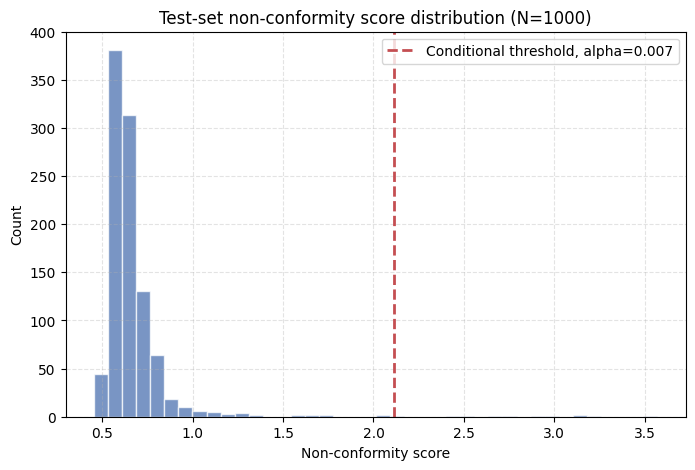

Fraction of test trajectories with score < calibration quantile: 0.9900
Reference 1-alpha: 0.9500
0.9900 > 0.9500. Verification passed.


In [6]:
# Sample an independent test set for NC evaluation
nc_test_w = generate_random_batch(
    batch_size=test_dataset_size,
    horizon=horizon,
    n_agents=n_agents,
    x0_std=x0_std,
    noise_std=noise_std,
    device=device,
)
nc_test_traj = {}
pb_loop.eval()
with torch.no_grad():
    nc_test_traj["x"], nc_test_traj["u"], nc_test_traj["w_hat"] = pb_loop.run(nc_test_w)

# Compute non-conformity scores for test trajectories and evaluate calibration quantile violation
test_nc_scores = nonconformity.compute_nonconformity_scores(nc_test_traj, scorer)
threshold = calibration_result.threshold

# Plot test non-conformity score distribution and threshold
fraction_lower_than_threshold = (test_nc_scores < threshold).float().mean().item()
plot_functions.plot_nonconformity_scores(
    scores=test_nc_scores,
    threshold=threshold,
    alpha=alpha_conditional,
    bins=40,
)
plt.title(f"Test-set non-conformity score distribution (N={test_dataset_size})")
plt.show()

print(f"Fraction of test trajectories with score < calibration quantile: {fraction_lower_than_threshold:.4f}")
print(f"Reference 1-alpha: {1.0 - alpha:.4f}")
print(f"{fraction_lower_than_threshold:.4f} > {1.0 - alpha:.4f}. Verification passed." if fraction_lower_than_threshold >= 1 - alpha else f"{fraction_lower_than_threshold} < {1.0 - alpha:.4f}. Verification failed.")

### Repeated experimentation for empirical estimation of delta

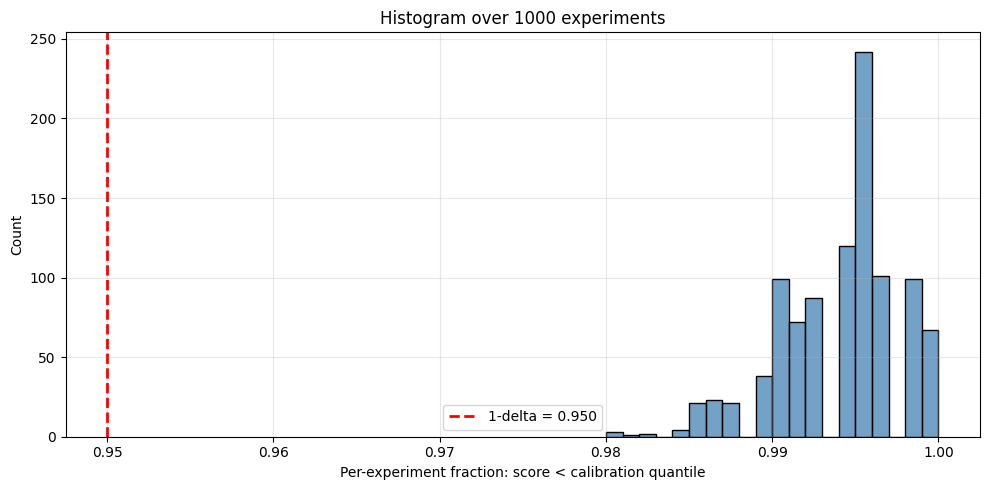

Empirical estimate P(fraction >= 1-delta): 1.0000


In [7]:
fractions_below_quantile = []

pb_loop.eval()
with torch.no_grad():
    for _ in range(nb_experiments):
        # 1) Calibration split for this experiment
        calibration_w_i = generate_random_batch(
            batch_size=m_cert,
            horizon=horizon,
            n_agents=n_agents,
            x0_std=x0_std,
            noise_std=noise_std,
            device=device,
        )
        traj_cal_i = {}
        traj_cal_i["x"], traj_cal_i["u"], traj_cal_i["w_hat"] = pb_loop.run(calibration_w_i)

        calibration_result_i = nonconformity.calibrate_nonconformity(
            trajectories=traj_cal_i,
            scorer=scorer,
            alpha=alpha_conditional,
            finite_sample=True,
        )

        # 2) Independent test split for this experiment
        test_w_i = generate_random_batch(
            batch_size=test_dataset_size,
            horizon=horizon,
            n_agents=n_agents,
            x0_std=x0_std,
            noise_std=noise_std,
            device=device,
        )
        traj_test_i = {}
        traj_test_i["x"], traj_test_i["u"], traj_test_i["w_hat"] = pb_loop.run(test_w_i)

        test_scores_i = nonconformity.compute_nonconformity_scores(traj_test_i, scorer)

        fraction_i = (test_scores_i < calibration_result_i.threshold).float().mean().item()
        fractions_below_quantile.append(fraction_i)

fractions_below_quantile = np.asarray(fractions_below_quantile)

# Empirical estimate: P( fraction >= 1 - delta )
empirical_prob_above_1_minus_delta = np.mean(fractions_below_quantile >= (1.0 - delta))

plt.figure(figsize=(10, 5))
sns.histplot(fractions_below_quantile, bins=20, kde=False, color="steelblue")
plt.axvline(1.0 - delta, color="red", linestyle="--", linewidth=2, label=f"1-delta = {1.0 - delta:.3f}")
plt.xlabel("Per-experiment fraction: score < calibration quantile")
plt.ylabel("Count")
plt.title(f"Histogram over {nb_experiments} experiments")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Empirical estimate P(fraction >= 1-delta): {empirical_prob_above_1_minus_delta:.4f}")

# Extra

### Generate test data

In [8]:
test_w = generate_random_batch(
    batch_size=num_test_samples,
    horizon=horizon,
    n_agents=config.n_agents,
    x0_std=x0_std,
    noise_std=noise_std,
    device=ctx['device']
)

pb_loop = eval_system['pb_loop']
pb_loop.eval()

with torch.no_grad():
    traj_x, traj_u, traj_w_hat = pb_loop.run(test_w)

print(f'Test set shape: {test_w.shape}')
print(f'Trajectory x shape: {traj_x.shape}')
print(f'Trajectory u shape: {traj_u.shape}')
print(f'Trajectory w_hat shape: {traj_w_hat.shape}')

Test set shape: torch.Size([500, 300, 4])
Trajectory x shape: torch.Size([500, 300, 4])
Trajectory u shape: torch.Size([500, 300, 2])
Trajectory w_hat shape: torch.Size([500, 300, 4])


### Compute cost statistics

In [9]:
with torch.no_grad():
    costs = metric.compute_per_sample_cost(traj_x, traj_u).cpu().numpy()

mean_cost = np.mean(costs)
std_cost = np.std(costs)
min_cost = np.min(costs)
max_cost = np.max(costs)
q50 = np.quantile(costs, 0.50)
q95 = np.quantile(costs, 0.95)

print('=' * 60)
print('PERFORMANCE STATISTICS (Test Set)')
print('=' * 60)
print(f'Mean Cost:         {mean_cost:.4f}')
print(f'Std Dev:           {std_cost:.4f}')
print(f'Median (50%):      {q50:.4f}')
print(f'95th Percentile:   {q95:.4f}')
print(f'Minimum Cost:      {min_cost:.4f}')
print(f'Maximum Cost:      {max_cost:.4f}')
print(f'Test Set Size:     {num_test_samples}')
print('=' * 60)

PERFORMANCE STATISTICS (Test Set)
Mean Cost:         0.6573
Std Dev:           0.1585
Median (50%):      0.6204
95th Percentile:   0.9051
Minimum Cost:      0.4555
Maximum Cost:      2.0536
Test Set Size:     500


### Plot cost distribution

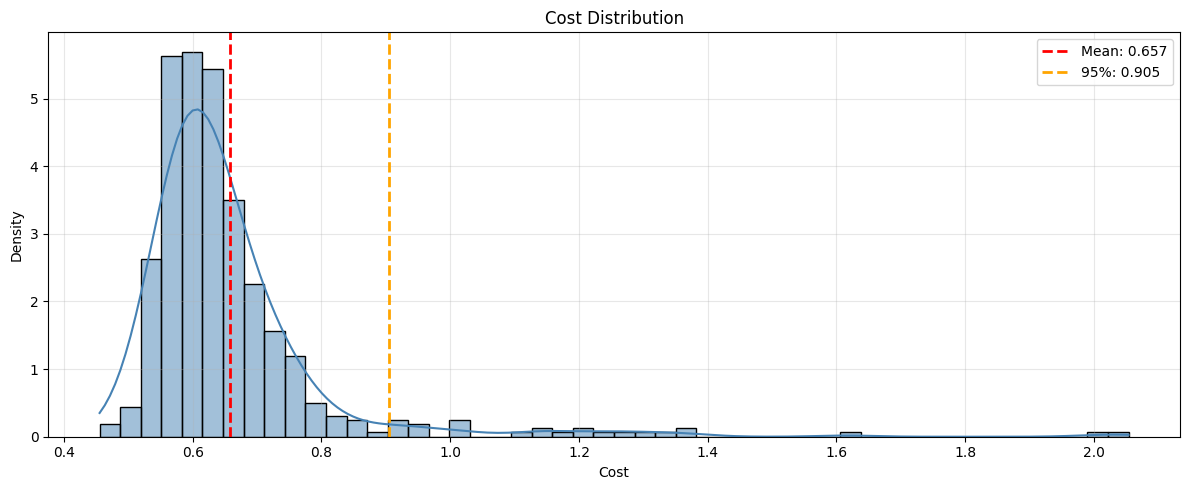

In [10]:
plt.figure(figsize=(12, 5))

sns.histplot(costs, bins=50, kde=True, stat='density', color='steelblue')
plt.axvline(mean_cost, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_cost:.3f}')
plt.axvline(q95, color='orange', linestyle='--', linewidth=2, label=f'95%: {q95:.3f}')
plt.xlabel('Cost')
plt.ylabel('Density')
plt.title('Cost Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualize trajectories

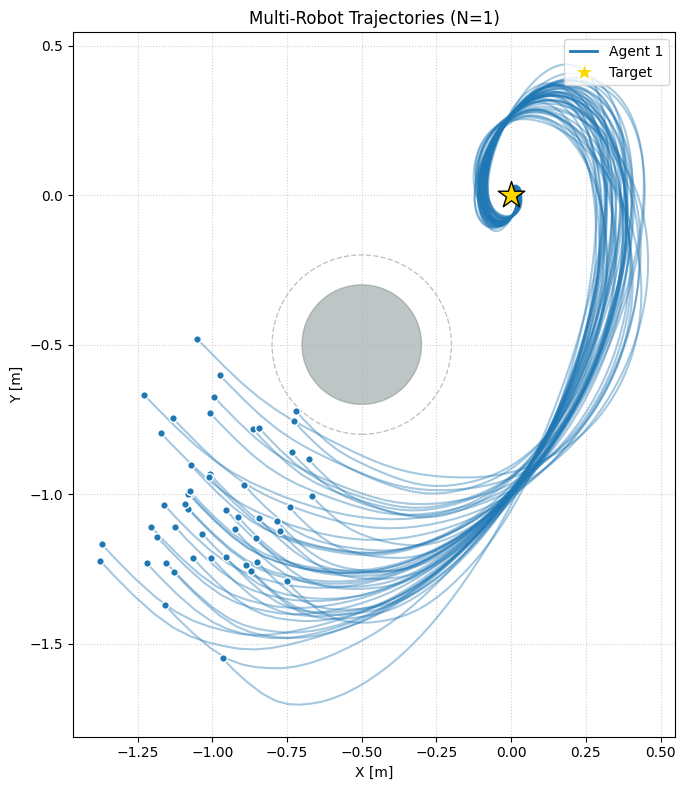

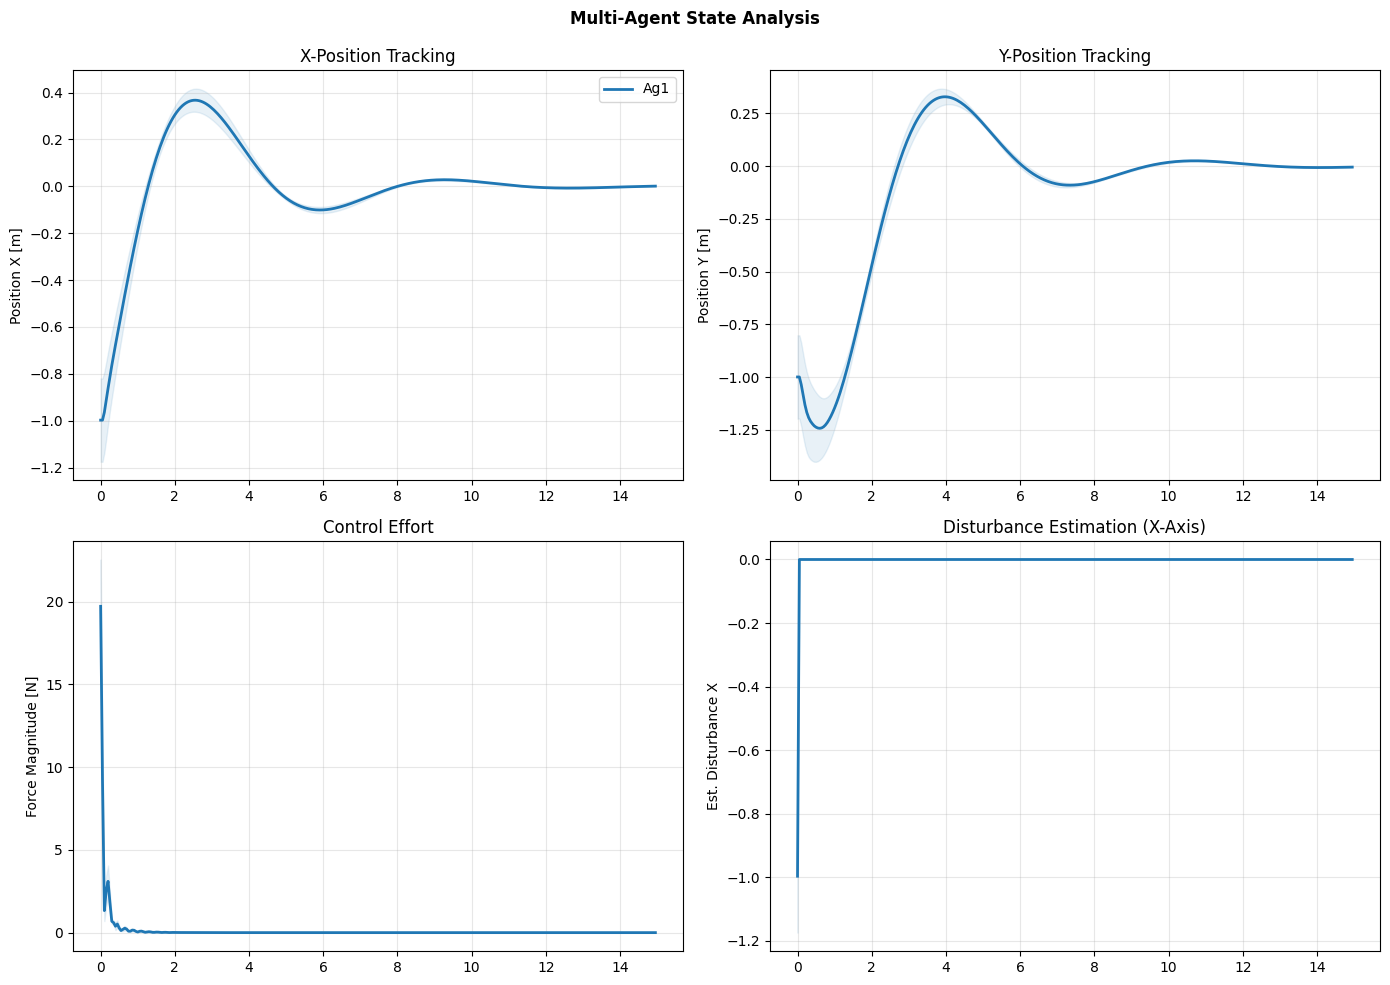

In [11]:
plot_pb_trajectories(
    traj_x=traj_x,
    traj_u=traj_u,
    traj_w_hat=traj_w_hat,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=config.dt
)